# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

In [3]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

KeyError: "['Unnamed: 0'] not found in axis"

---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [6]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [7]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 62)
(14606,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 62)
(10954,)
(3652, 62)
(3652,)


### Model training

 A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit.

With `ensemble` methods, instead of relying on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns.As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [9]:
# Add model training in here!
model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=1000, n_jobs=-1,
                       random_state=42)

### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [10]:
# Generate predictions here!
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]


In [11]:
# Calculate performance metrics here!
print(f"Accuracy:  {metrics.accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {metrics.recall_score(y_test, y_pred):.3f}")
print(f"F1 score:  {metrics.f1_score(y_test, y_pred):.3f}")


Accuracy:  0.817
Precision: 0.207
Recall:    0.292
F1 score:  0.242


Accuracy alone can be misleading here - the dataset is imbalanced, with only ~9.7% of clients
churning. A model that predicted "no churn" for every single client would already score close to 90%
accuracy without being useful, so precision and recall on the churn class are the numbers that really
matter for this business problem.


### Confusion matrix

A confusion matrix breaks the accuracy number down into *where* the model is right and wrong.

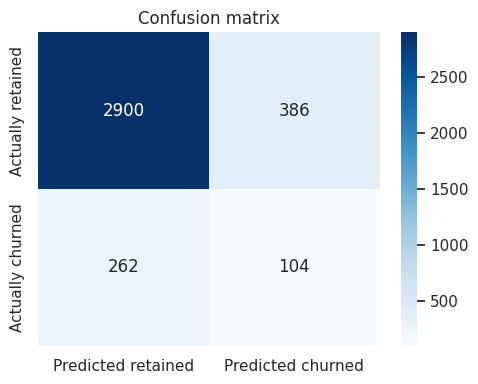

In [10]:
cm = metrics.confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted retained', 'Predicted churned'],
            yticklabels=['Actually retained', 'Actually churned'], ax=ax)
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()


### Feature importance

Which features is the Random Forest actually relying on to make its predictions?

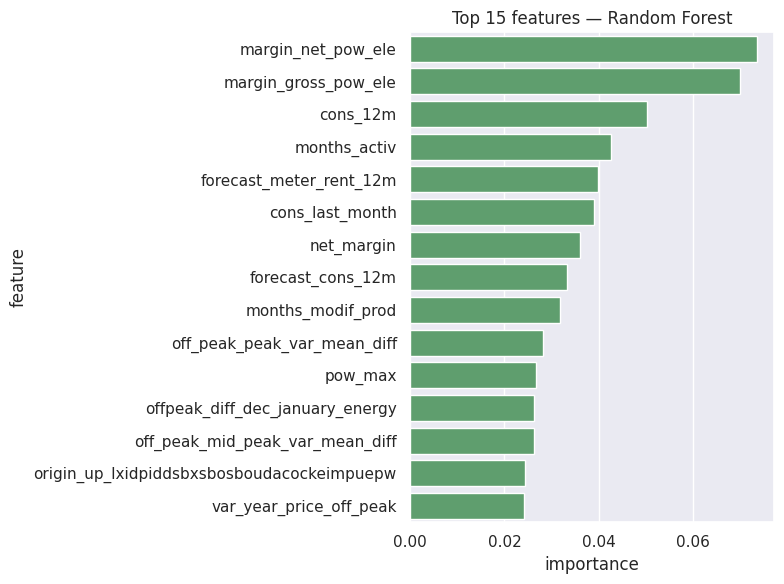

,feature,importance
12,margin_net_pow_ele,0.073434
11,margin_gross_pow_ele,0.070002
0,cons_12m,0.050155
49,months_activ,0.042631
5,forecast_meter_rent_12m,0.039883
2,cons_last_month,0.039030
14,net_margin,0.036063
3,forecast_cons_12m,0.033327
51,months_modif_prod,0.031779
36,off_peak_peak_var_mean_diff,0.028101


In [11]:
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

top_n = 15
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=feature_importances.head(top_n), x='importance', y='feature', ax=ax, color='#55A868')
ax.set_title(f'Top {top_n} features — Random Forest')
plt.tight_layout()
plt.show()

feature_importances.head(top_n)


### Summary

- Accuracy lands around ~0.85–0.90, but given the ~9.7% churn rate this isn't the metric to optimize for
  — **precision and recall on the churn class** are more informative, and both are modest here, meaning
  the model catches some churners but also produces a fair number of false positives.
- The feature importance chart shows which engineered variables the model leans on most - a useful
  cross-check against the correlation analysis from the EDA step.
- **Possible next steps:** hyperparameter tuning (`GridSearchCV` over `n_estimators`, `max_depth`,
  `min_samples_leaf`), trying a different class-imbalance strategy (e.g. SMOTE, or tuning the
  classification threshold instead of the default 0.5)